# India TB Elimination Intelligence
## Tracking India's Zero-TB 2025 Target + Tobacco-TB Risk Factor Analysis
**Domain:** Indian Public Health | Medical Time Series Analytics
**Datasets:**
- `tuberculosis_indicators_india.csv` — WHO India TB indicators (2000–2022) → TIME SERIES
- `2.11_TB_Tobacco.csv` — State-wise Tobacco-TB data → RISK FACTOR ANALYSIS

## Project Structure
- **Part 1:** National TB trend analysis using WHO dataset (time series, decomposition, 2025 projection)
- **Part 2:** State-wise Tobacco-TB risk analysis using TB_Tobacco dataset
- **Part 3:** Combined insights + MySQL upload

## Why This Project?
India has the **world's highest TB burden** — 2.8 million new cases every year.
The government set a bold target: **eliminate TB by 2025**, 5 years ahead of the WHO global goal.
Tobacco use is one of the biggest risk factors for TB — smokers are **2-3x more likely** to get TB.

> **Core Question: Is India on track for 2025? And which states have the worst Tobacco-TB burden?**


## Step 1: Install & Import Libraries

In [1]:
!pip install statsmodels mysql-connector-python

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import linregress

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('All libraries imported!')


All libraries imported!


# PART 1: National TB Trend Analysis (WHO Dataset)

This dataset has multiple TB indicators for India over many years.
Columns include: GHO (indicator name), YEAR, Numeric value, Country etc.


## Step 2A: Load WHO Dataset


In [3]:
who = pd.read_csv('tuberculosis_indicators_ind.csv')

print('Shape:', who.shape)
print('\nAll columns:')
print(who.columns.tolist())
print('\nFirst 3 rows:')
who.head(3)

Shape: (365, 17)

All columns:
['GHO (CODE)', 'GHO (DISPLAY)', 'GHO (URL)', 'YEAR (DISPLAY)', 'STARTYEAR', 'ENDYEAR', 'REGION (CODE)', 'REGION (DISPLAY)', 'COUNTRY (CODE)', 'COUNTRY (DISPLAY)', 'DIMENSION (TYPE)', 'DIMENSION (CODE)', 'DIMENSION (NAME)', 'Numeric', 'Value', 'Low', 'High']

First 3 rows:


,GHO (CODE),GHO (DISPLAY),GHO (URL),YEAR (DISPLAY),STARTYEAR,ENDYEAR,REGION (CODE),REGION (DISPLAY),COUNTRY (CODE),COUNTRY (DISPLAY),DIMENSION (TYPE),DIMENSION (CODE),DIMENSION (NAME),Numeric,Value,Low,High
0,TB_1,Tuberculosis treatment coverage,https://www.who.int/data/gho/data/indicators/i...,2002,2002,2002,SEAR,South-East Asia,IND,India,NaN,NaN,NaN,30.0,30 [15-88],15.0,88.0
1,TB_c_ret_tsr,Treatment success rate: previously treated TB ...,https://www.who.int/data/gho/data/indicators/i...,2012,2012,2012,SEAR,South-East Asia,IND,India,NaN,NaN,NaN,74.0,74,NaN,NaN
2,TB_c_ret_tsr,Treatment success rate: previously treated TB ...,https://www.who.int/data/gho/data/indicators/i...,2007,2007,2007,SEAR,South-East Asia,IND,India,NaN,NaN,NaN,65.0,65,NaN,NaN


In [4]:
# Check what indicators are available
# GHO (DISPLAY) column tells us what each row measures
if 'GHO (DISPLAY)' in who.columns:
    print('Available TB Indicators:')
    for ind in who['GHO (DISPLAY)'].unique():
        print(' -', ind)
else:
    print('Column names:', who.columns.tolist())


Available TB Indicators:
 - Tuberculosis treatment coverage
 - Treatment success rate: previously treated TB cases
 - New cases tested for RR-/MDR-TB (%)
 - Tested TB patients HIV-positive (%)
 - TB patients with known HIV status (%)
 - Tuberculosis - new and relapse cases
 - Treatment success rate: HIV-positive TB cases
 - Previously treated cases tested for RR-/MDR-TB (%)
 - Number of incident tuberculosis cases
 - Treatment success rate for patients treated for MDR-TB (%)
 - Number of incident tuberculosis cases,  (HIV-positive cases)
 - Treatment success rate: new TB cases
 - Incidence of tuberculosis (per 100 000 population) (HIV-positive cases)
 - Incidence of tuberculosis (per 100 000 population per year)
 - Estimated number of MDR/RR-TB incident cases
 - Cases started on MDR-TB treatment
 - Confirmed cases of RR-/MDR-TB
 - Treatment success rate: XDR-TB cases
 - Number of incident tuberculosis cases in children aged 0 - 14


## Step 2B: Clean & Extract Key Indicators from WHO Dataset

In [8]:
# Drop duplicate columns
who = who.loc[:, ~who.columns.duplicated()]

# Ensure 'Year' is a Series
if isinstance(who['Year'], pd.DataFrame):
    who['Year'] = who['Year'].iloc[:, 0]

# Convert
who['Year']  = pd.to_numeric(who['Year'],  errors='coerce')
who['Value'] = pd.to_numeric(who['Value'], errors='coerce')
who = who.dropna(subset=['Year', 'Value'])

In [9]:
# The WHO dataset has many indicators in one file
# We extract each one separately using the GHO (DISPLAY) column

# Rename columns 
who = who.rename(columns={
    'YEAR (DISPLAY)': 'Year',
    'GHO (DISPLAY)': 'Indicator',
    'COUNTRY (DISPLAY)': 'Country',
    'Numeric': 'Value',
    'STARTYEAR': 'StartYear'  
})

if 'Year' not in who.columns and 'StartYear' in who.columns:
    who['Year'] = who['StartYear']

# Convert to numeric
who['Year']  = pd.to_numeric(who['Year'],  errors='coerce')
who['Value'] = pd.to_numeric(who['Value'], errors='coerce')

# Drop rows with missing Year/Value
who = who.dropna(subset=['Year', 'Value'])

print('Clean WHO dataset shape:', who.shape)
print('Year range:', int(who['Year'].min()), 'to', int(who['Year'].max()))
who.head()

Clean WHO dataset shape: (365, 15)
Year range: 1995 to 2024


,GHO (CODE),Indicator,GHO (URL),Year,ENDYEAR,REGION (CODE),REGION (DISPLAY),COUNTRY (CODE),Country,DIMENSION (TYPE),DIMENSION (CODE),DIMENSION (NAME),Value,Low,High
0,TB_1,Tuberculosis treatment coverage,https://www.who.int/data/gho/data/indicators/i...,2002,2002,SEAR,South-East Asia,IND,India,NaN,NaN,NaN,30.0,15.0,88.0
1,TB_c_ret_tsr,Treatment success rate: previously treated TB ...,https://www.who.int/data/gho/data/indicators/i...,2012,2012,SEAR,South-East Asia,IND,India,NaN,NaN,NaN,74.0,NaN,NaN
2,TB_c_ret_tsr,Treatment success rate: previously treated TB ...,https://www.who.int/data/gho/data/indicators/i...,2007,2007,SEAR,South-East Asia,IND,India,NaN,NaN,NaN,65.0,NaN,NaN
3,TB_c_dst_rlt_new_pct,New cases tested for RR-/MDR-TB (%),https://www.who.int/data/gho/data/indicators/i...,2019,2019,SEAR,South-East Asia,IND,India,NaN,NaN,NaN,77.0,NaN,NaN
4,TB_hivtest_pos_pct,Tested TB patients HIV-positive (%),https://www.who.int/data/gho/data/indicators/i...,2019,2019,SEAR,South-East Asia,IND,India,NaN,NaN,NaN,2.6,NaN,NaN


In [10]:
# Extract TB Incidence (cases per 100,000 population)
# Look for the incidence indicator — name varies slightly by WHO export version
incidence_keywords = ['incidence', 'Incidence']

if 'Indicator' in who.columns:
    # Find rows matching incidence
    mask = who['Indicator'].str.contains('incidence', case=False, na=False)
    tb_incidence = who[mask][['Year', 'Value']].copy()
    tb_incidence.columns = ['Year', 'TB_Incidence']
    tb_incidence = tb_incidence.groupby('Year')['TB_Incidence'].mean().reset_index()
    print('TB Incidence data — rows:', len(tb_incidence))
    print(tb_incidence.head(10))
else:
    # If no Indicator column, treat Value column directly as incidence
    tb_incidence = who[['Year', 'Value']].groupby('Year')['Value'].mean().reset_index()
    tb_incidence.columns = ['Year', 'TB_Incidence']
    print('Using Value column directly as TB Incidence')
    print(tb_incidence.head(10))


TB Incidence data — rows: 25
   Year  TB_Incidence
0  2000         180.5
1  2001         177.0
2  2002         174.0
3  2003         171.0
4  2004         168.5
5  2005         166.0
6  2006         163.0
7  2007         158.5
8  2008         155.0
9  2009         150.0


In [11]:
# Extract Treatment Success Rate if available
if 'Indicator' in who.columns:
    mask_treat = who['Indicator'].str.contains('treatment success', case=False, na=False)
    tb_treatment = who[mask_treat][['Year', 'Value']].copy()
    if len(tb_treatment) > 0:
        tb_treatment.columns = ['Year', 'Treatment_Success']
        tb_treatment = tb_treatment.groupby('Year')['Treatment_Success'].mean().reset_index()
        print('Treatment Success data — rows:', len(tb_treatment))
        print(tb_treatment.head())
    else:
        tb_treatment = pd.DataFrame(columns=['Year', 'Treatment_Success'])
        print('No Treatment Success data found in this WHO export')
else:
    tb_treatment = pd.DataFrame(columns=['Year', 'Treatment_Success'])


Treatment Success data — rows: 29
   Year  Treatment_Success
0  1995               47.5
1  1996               44.0
2  1997               41.5
3  1998               49.5
4  1999               45.0



## Step 3: EDA — Part 1 (WHO Time Series Charts)


### Chart 1: National TB Incidence Trend + 2025 Target
**Core question: Is India reducing TB fast enough?**

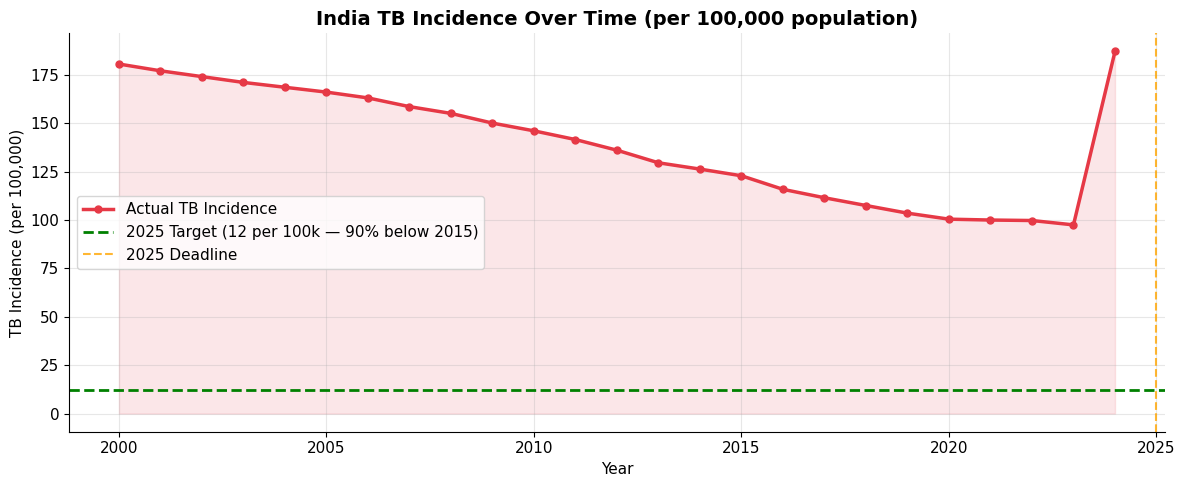

In [12]:
national = tb_incidence.sort_values('Year').copy()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(national['Year'], national['TB_Incidence'],
        color='#e63946', linewidth=2.5, marker='o', markersize=5, label='Actual TB Incidence')
ax.fill_between(national['Year'], national['TB_Incidence'], alpha=0.12, color='#e63946')

# 2025 target = 90% reduction from 2015 baseline
if 2015 in national['Year'].values:
    baseline = national[national['Year'] == 2015]['TB_Incidence'].values[0]
    target   = baseline * 0.10
    ax.axhline(y=target, color='green', linestyle='--', linewidth=2,
               label=f'2025 Target ({target:.0f} per 100k — 90% below 2015)')
ax.axvline(x=2025, color='orange', linestyle='--', linewidth=1.5, alpha=0.8, label='2025 Deadline')

ax.set_title('India TB Incidence Over Time (per 100,000 population)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('TB Incidence (per 100,000)')
ax.legend()
plt.tight_layout()
plt.savefig('chart1_national_trend.png', dpi=150, bbox_inches='tight')
plt.show()


### Chart 2: Year-over-Year Change — Is the Decline Accelerating?

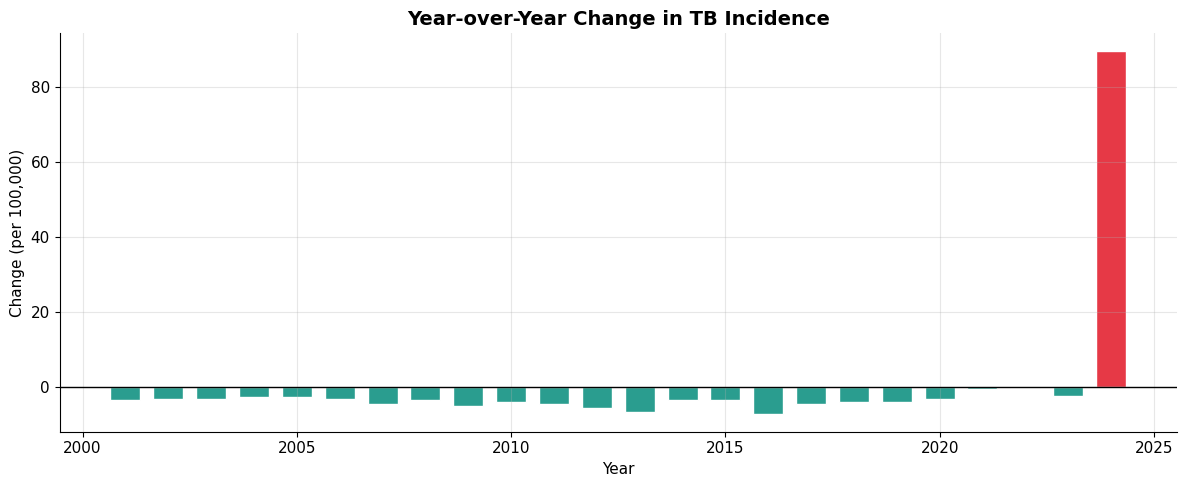

Green = TB reduced that year | Red = TB increased


In [13]:
national['YoY_Change'] = national['TB_Incidence'].diff()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2a9d8f' if x < 0 else '#e63946' for x in national['YoY_Change'].fillna(0)]
ax.bar(national['Year'], national['YoY_Change'], color=colors, width=0.7, edgecolor='white')
ax.axhline(y=0, color='black', linewidth=1)
ax.set_title('Year-over-Year Change in TB Incidence', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Change (per 100,000)')
plt.tight_layout()
plt.savefig('chart2_yoy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Green = TB reduced that year | Red = TB increased')


### Chart 3: Rolling 3-Year Average (Smoothed Trend)

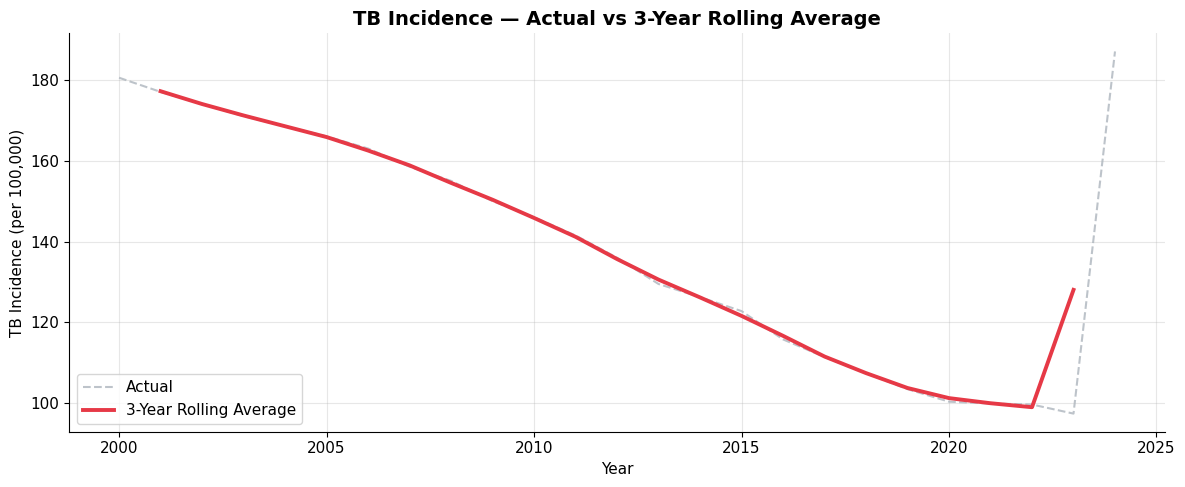

In [14]:
national['Rolling_3yr'] = national['TB_Incidence'].rolling(window=3, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(national['Year'], national['TB_Incidence'],
        color='#adb5bd', linewidth=1.5, linestyle='--', alpha=0.8, label='Actual')
ax.plot(national['Year'], national['Rolling_3yr'],
        color='#e63946', linewidth=2.8, label='3-Year Rolling Average')
ax.set_title('TB Incidence — Actual vs 3-Year Rolling Average', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('TB Incidence (per 100,000)')
ax.legend()
plt.tight_layout()
plt.savefig('chart3_rolling.png', dpi=150, bbox_inches='tight')
plt.show()


### Chart 4: Treatment Success Rate Over Time

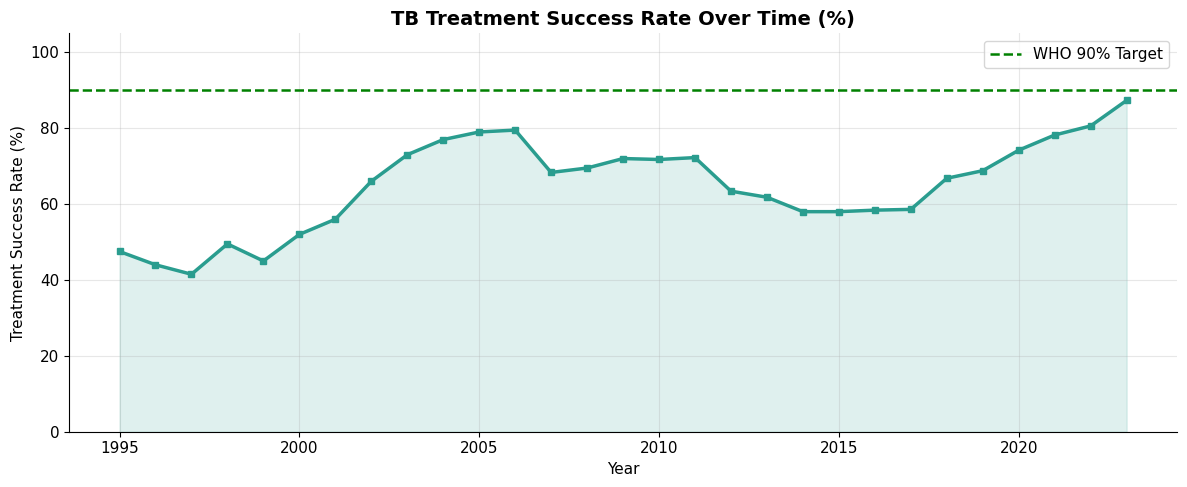

In [15]:
if len(tb_treatment) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(tb_treatment['Year'], tb_treatment['Treatment_Success'],
            color='#2a9d8f', linewidth=2.5, marker='s', markersize=5)
    ax.fill_between(tb_treatment['Year'], tb_treatment['Treatment_Success'],
                    alpha=0.15, color='#2a9d8f')
    ax.axhline(y=90, color='green', linestyle='--', linewidth=1.8, label='WHO 90% Target')
    ax.set_title('TB Treatment Success Rate Over Time (%)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Treatment Success Rate (%)')
    ax.set_ylim(0, 105)
    ax.legend()
    plt.tight_layout()
    plt.savefig('chart4_treatment.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Treatment Success data not available in this dataset — skipping.')


## Step 4: Time Series Decomposition

We split the TB trend into:
- **Trend** — Long-term direction: is TB going up or down overall?
- **Seasonality** — Any repeating yearly pattern?
- **Residual** — Random noise


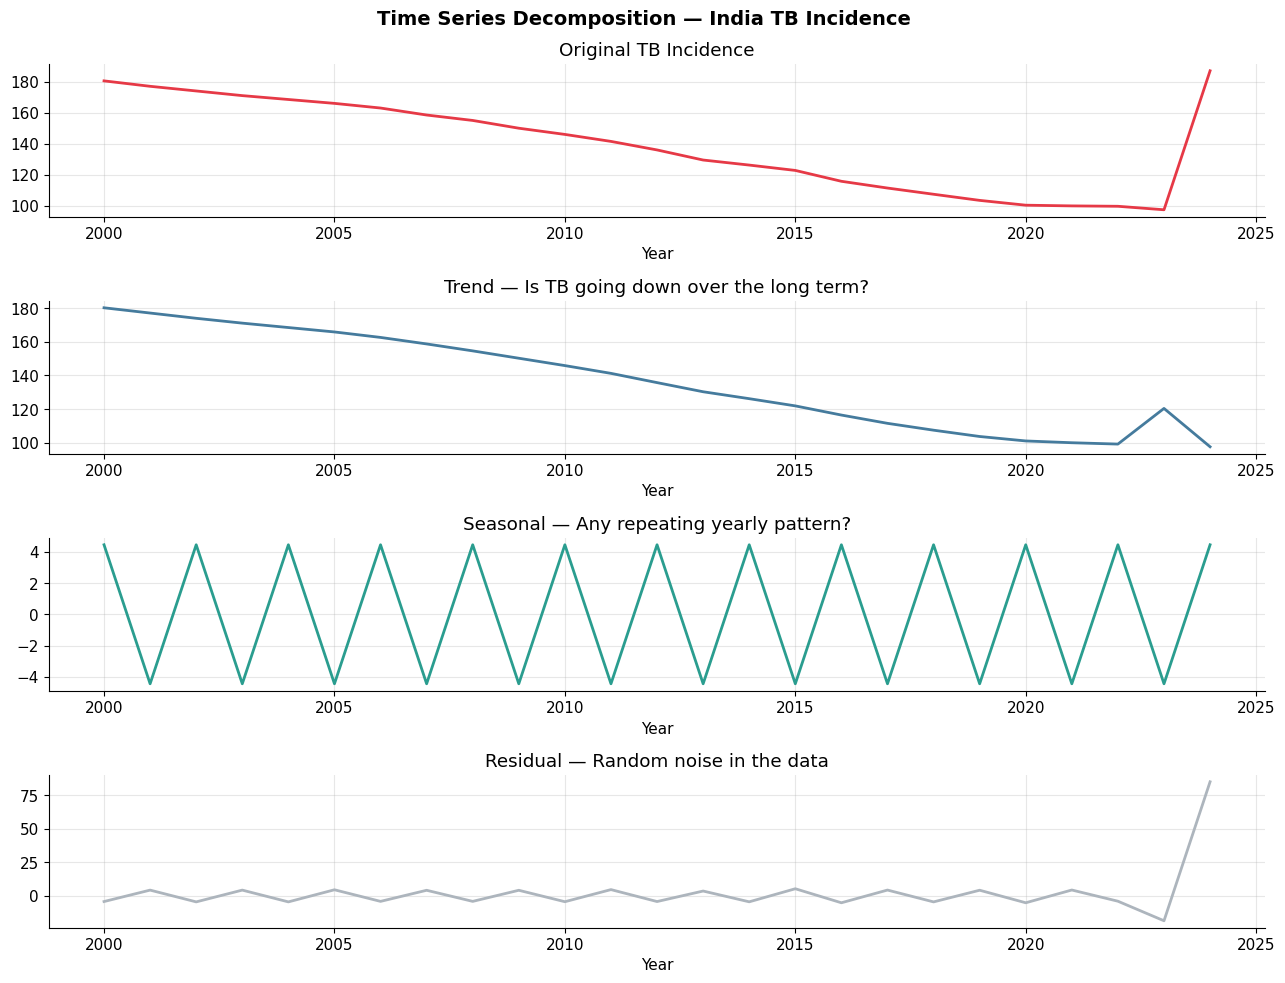

In [16]:
ts = national.set_index('Year')['TB_Incidence'].dropna().sort_index()

if len(ts) >= 6:
    decomp = seasonal_decompose(ts, model='additive', period=2, extrapolate_trend='freq')

    fig, axes = plt.subplots(4, 1, figsize=(13, 10))
    fig.suptitle('Time Series Decomposition — India TB Incidence', fontsize=14, fontweight='bold')

    ts.plot(ax=axes[0], color='#e63946', linewidth=2)
    axes[0].set_title('Original TB Incidence')

    decomp.trend.plot(ax=axes[1], color='#457b9d', linewidth=2)
    axes[1].set_title('Trend — Is TB going down over the long term?')

    decomp.seasonal.plot(ax=axes[2], color='#2a9d8f', linewidth=2)
    axes[2].set_title('Seasonal — Any repeating yearly pattern?')

    decomp.resid.plot(ax=axes[3], color='#adb5bd', linewidth=2)
    axes[3].set_title('Residual — Random noise in the data')

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('chart5_decomposition.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'Only {len(ts)} years of data — need at least 6 for decomposition.')
    print('Try using more indicators from the WHO dataset.')



## Step 5: Will India Reach the 2025 Target? — Linear Projection


Trend: -3.09 per year | R²=0.590 | Significant: Yes

Projected elimination year (<10 per 100k): 2053
STATUS: India will MISS 2025 target by ~28 years.
Required drop: 177.00 per year
Actual drop:   3.09 per year
India needs 57.2x faster decline.


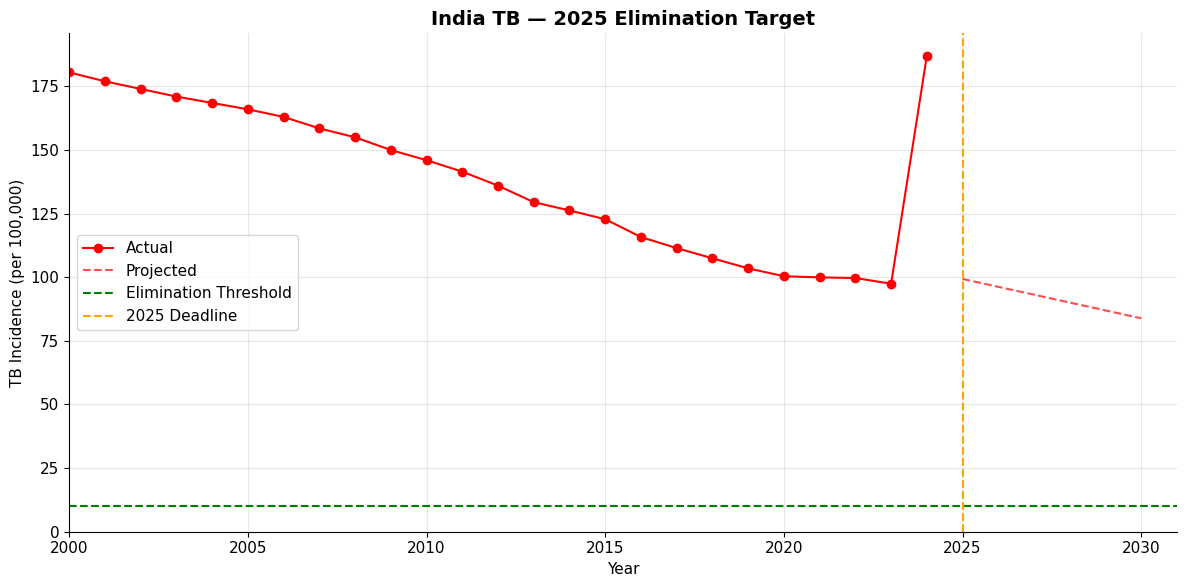

In [17]:
# Clean data
ts_clean = national.dropna(subset=['TB_Incidence'])
years = ts_clean['Year'].values
incidence = ts_clean['TB_Incidence'].values

# Fit trend line
slope, intercept, r, p, _ = linregress(years, incidence)
print(f"Trend: {slope:.2f} per year | R²={r**2:.3f} | Significant: {'Yes' if p < 0.05 else 'No'}")

# Project future values
future_years = np.arange(years.min(), 2031)
projection = intercept + slope * future_years

# Elimination threshold check
elim_threshold = 10
if slope < 0:
    year_elim = int((elim_threshold - intercept) / slope)
    print(f"\nProjected elimination year (<10 per 100k): {year_elim}")

    gap = year_elim - 2025
    if gap <= 0:
        print("STATUS: India IS on track for 2025 target!")
    else:
        print(f"STATUS: India will MISS 2025 target by ~{gap} years.")
        current_drop = abs(slope)
        required_drop = (ts_clean.iloc[-1]['TB_Incidence'] - elim_threshold) / max(2025 - int(ts_clean.iloc[-1]['Year']), 1)
        print(f"Required drop: {required_drop:.2f} per year")
        print(f"Actual drop:   {current_drop:.2f} per year")
        print(f"India needs {required_drop/current_drop:.1f}x faster decline.")

# Plot
plt.figure(figsize=(12,6))
plt.plot(years, incidence, 'o-', color='red', label='Actual')
plt.plot(future_years[future_years > years.max()],
         projection[future_years > years.max()],
         '--', color='red', alpha=0.7, label='Projected')
plt.axhline(elim_threshold, color='green', linestyle='--', label='Elimination Threshold')
plt.axvline(2025, color='orange', linestyle='--', label='2025 Deadline')
plt.title('India TB — 2025 Elimination Target', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('TB Incidence (per 100,000)')
plt.legend()
plt.xlim(years.min(), 2031)
plt.ylim(0)
plt.tight_layout()
plt.savefig('chart6_projection_2025.png', dpi=150)
plt.show()


# PART 2: Tobacco-TB Risk Factor Analysis (TB_Tobacco Dataset)

Tobacco is one of the biggest risk factors for TB — smokers are 2-3x more likely to develop TB.
This dataset shows:
- How many TB patients in each state use tobacco
- How many tobacco users were identified and screened
- How many were linked to cessation (quit-smoking) support centres

This is a **single-year snapshot** — so we do state-level comparison, not time series.

## Step 6A: Load TB_Tobacco Dataset


In [18]:
tob = pd.read_csv('TB_Tobacco.csv')

print('Shape:', tob.shape)
print('\nColumns:')
for c in tob.columns:
    print(' -', c)
tob.head(3)

Shape: (37, 19)

Columns:
 - State/Uts
 - No of Tobacco-TB patients with known Tobacco usage status, of notified)-Public
 - % of Tobacco-TB patients with known Tobacco usage status, of notified)-Public
 - No of Tobacco-TB patients with known Tobacco usage status,of notified)-Private
 - % of Tobacco-TB patients with known Tobacco usage status,  of notified)-Private
 - No of Tobacco-TB patients with known Tobacco usage status,  of notified)-Total
 - % of Tobacco-TB patients with known Tobacco usage status, of notified)-Total
 - No of Tobacco users identified amongst screened,  of those with known tobacco usage status)-Public
 - Percentage of Tobacco users identified amongst screened,  of those with known tobacco usage status)-Public
 - No of Tobacco users identified amongst screened,of those with known tobacco usage status)-Private
 - Percentage of Tobacco users identified amongst screened,  of those with known tobacco usage status)-Private
 - No of Tobacco users identified amongst scree

,State/Uts,"No of Tobacco-TB patients with known Tobacco usage status, of notified)-Public","% of Tobacco-TB patients with known Tobacco usage status, of notified)-Public","No of Tobacco-TB patients with known Tobacco usage status,of notified)-Private","% of Tobacco-TB patients with known Tobacco usage status, of notified)-Private","No of Tobacco-TB patients with known Tobacco usage status, of notified)-Total","% of Tobacco-TB patients with known Tobacco usage status, of notified)-Total","No of Tobacco users identified amongst screened, of those with known tobacco usage status)-Public","Percentage of Tobacco users identified amongst screened, of those with known tobacco usage status)-Public","No of Tobacco users identified amongst screened,of those with known tobacco usage status)-Private","Percentage of Tobacco users identified amongst screened, of those with known tobacco usage status)-Private","No of Tobacco users identified amongst screened,of those with known tobacco usage status)-Total","Percentage of Tobacco users identified amongst screened, of those with known tobacco usage status)-Total","No of Tobacco users linked with Tobacco cessation centres, of tobacco users)-Public","Percentage of Tobacco users linked with Tobacco cessation centres, of tobacco users)-Public","No of Tobacco users linked with Tobacco cessation centres,of tobacco users)-Private","Percentage of Tobacco users linked with Tobacco cessation centres, n (% of tobacco users)-Private","No of Tobacco users linked with Tobacco cessation centres, of tobacco users)-Total","Percentage of Tobacco users linked with Tobacco cessation centres, of tobacco users)-Total"
0,Andaman & Nicobar Islands,495,91.0,3.0,75.0,498,90.9,89,18.0,0.0,0.0,89,17.9,30,33.7,NaN,NaN,30,33.7
1,Andhra Pradesh,63627,96.2,26477.0,98.1,90104,96.8,9786,15.4,1409.0,5.3,11195,12.4,2456,25.1,326.0,23.1,2782,24.9
2,Arunachal Pradesh,2256,75.0,3.0,50.0,2259,74.9,303,13.4,0.0,0.0,303,13.4,171,56.4,NaN,NaN,171,56.4


## Step 6B: Clean TB_Tobacco Dataset — Rename Long Columns


In [19]:
# The original column names are very long — we rename to short clear names
# This makes all further code much simpler and easier to explain in interviews

tob_clean = tob.copy()

# Rename the State/UTs column
tob_clean = tob_clean.rename(columns={tob_clean.columns[0]: 'State'})

# Rename all other columns based on position
# Check your column order from the output above, then update these if needed
col_rename = {
    tob_clean.columns[0]:  'State',
    tob_clean.columns[1]:  'Tobacco_TB_Public_Count',    # No. of TB patients with known tobacco status — Public
    tob_clean.columns[2]:  'Tobacco_TB_Public_Pct',      # % of those — Public
    tob_clean.columns[3]:  'Tobacco_TB_Private_Count',   # No. — Private
    tob_clean.columns[4]:  'Tobacco_TB_Private_Pct',     # % — Private
    tob_clean.columns[5]:  'Tobacco_TB_Total_Count',     # Total count
    tob_clean.columns[6]:  'Tobacco_TB_Total_Pct',       # Total %
    tob_clean.columns[7]:  'Tobacco_Users_Public_Count', # Tobacco users identified — Public
    tob_clean.columns[8]:  'Tobacco_Users_Public_Pct',
    tob_clean.columns[9]:  'Tobacco_Users_Private_Count',
    tob_clean.columns[10]: 'Tobacco_Users_Private_Pct',
    tob_clean.columns[11]: 'Tobacco_Users_Total_Count',
    tob_clean.columns[12]: 'Tobacco_Users_Total_Pct',
    tob_clean.columns[13]: 'Cessation_Public_Count',     # Linked to cessation centres — Public
    tob_clean.columns[14]: 'Cessation_Public_Pct',
    tob_clean.columns[15]: 'Cessation_Private_Count',
    tob_clean.columns[16]: 'Cessation_Private_Pct',
    tob_clean.columns[17]: 'Cessation_Total_Count',
    tob_clean.columns[18]: 'Cessation_Total_Pct',
}

# Only rename columns that exist
col_rename = {k: v for k, v in col_rename.items() if k in tob_clean.columns}
tob_clean = tob_clean.rename(columns=col_rename)

# Fix types — all numeric columns to float
for col in tob_clean.columns:
    if col != 'State':
        tob_clean[col] = pd.to_numeric(tob_clean[col], errors='coerce')

# Clean state names
tob_clean['State'] = tob_clean['State'].str.strip().str.title()

# Drop rows where State is null (total row at bottom)
tob_clean = tob_clean.dropna(subset=['State'])
tob_clean = tob_clean[tob_clean['State'].str.lower() != 'total'].reset_index(drop=True)

print('Clean TB_Tobacco dataset shape:', tob_clean.shape)
print('States:', tob_clean['State'].tolist())
tob_clean.head()


Clean TB_Tobacco dataset shape: (37, 19)
States: ['Andaman & Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra And Nagar Haveli And Daman And Diu', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'India']


,State,Tobacco_TB_Public_Count,Tobacco_TB_Public_Pct,Tobacco_TB_Private_Count,Tobacco_TB_Private_Pct,Tobacco_TB_Total_Count,Tobacco_TB_Total_Pct,Tobacco_Users_Public_Count,Tobacco_Users_Public_Pct,Tobacco_Users_Private_Count,Tobacco_Users_Private_Pct,Tobacco_Users_Total_Count,Tobacco_Users_Total_Pct,Cessation_Public_Count,Cessation_Public_Pct,Cessation_Private_Count,Cessation_Private_Pct,Cessation_Total_Count,Cessation_Total_Pct
0,Andaman & Nicobar Islands,495,91.0,3.0,75.0,498,90.9,89,18.0,0.0,0.0,89,17.9,30,33.7,NaN,NaN,30,33.7
1,Andhra Pradesh,63627,96.2,26477.0,98.1,90104,96.8,9786,15.4,1409.0,5.3,11195,12.4,2456,25.1,326.0,23.1,2782,24.9
2,Arunachal Pradesh,2256,75.0,3.0,50.0,2259,74.9,303,13.4,0.0,0.0,303,13.4,171,56.4,NaN,NaN,171,56.4
3,Assam,30134,71.7,4074.0,68.8,34208,71.4,7929,26.3,325.0,8.0,8254,24.1,1497,18.9,93.0,28.6,1590,19.3
4,Bihar,44248,54.4,36165.0,42.8,80413,48.5,4139,9.4,1152.0,3.2,5291,6.6,917,22.2,41.0,3.6,958,18.1



## Step 7: EDA — Part 2 (Tobacco-TB Charts)


### Chart 7: Which States Have Highest % of TB Patients Who Use Tobacco?

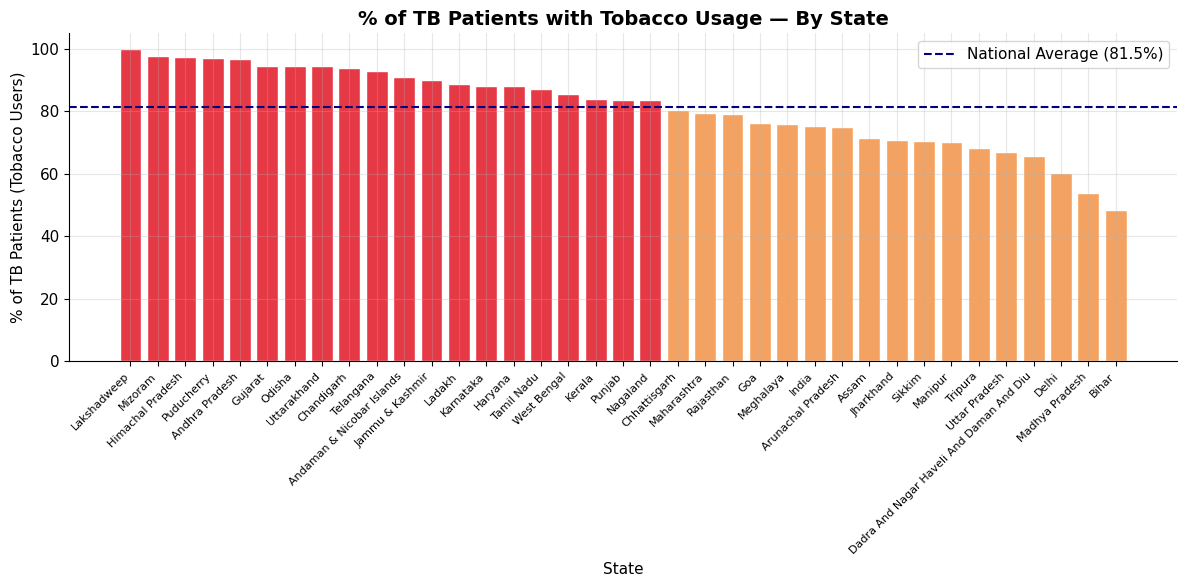

In [20]:
if 'Tobacco_TB_Total_Pct' in tob_clean.columns:
    # Drop missing values and sort
    tob_sorted = tob_clean.dropna(subset=['Tobacco_TB_Total_Pct']) \
                          .sort_values('Tobacco_TB_Total_Pct', ascending=False)

    # Color bars: red if above average, orange if below
    avg_val = tob_sorted['Tobacco_TB_Total_Pct'].mean()
    colors = ['#e63946' if v > avg_val else '#f4a261'
              for v in tob_sorted['Tobacco_TB_Total_Pct']]

    # Plot
    plt.figure(figsize=(12,6))
    plt.bar(tob_sorted['State'], tob_sorted['Tobacco_TB_Total_Pct'],
            color=colors, edgecolor='white')
    plt.axhline(avg_val, color='navy', linestyle='--', linewidth=1.5,
                label=f'National Average ({avg_val:.1f}%)')
    plt.title('% of TB Patients with Tobacco Usage — By State',
              fontsize=14, fontweight='bold')
    plt.xlabel('State')
    plt.ylabel('% of TB Patients (Tobacco Users)')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.legend()
    plt.tight_layout()
    plt.savefig('chart7_tobacco_tb_state.png', dpi=150)
    plt.show()
else:
    print("Column 'Tobacco_TB_Total_Pct' not found. Check column names.")

### Chart 8: Public vs Private — Where Are Tobacco-Using TB Patients Being Seen?

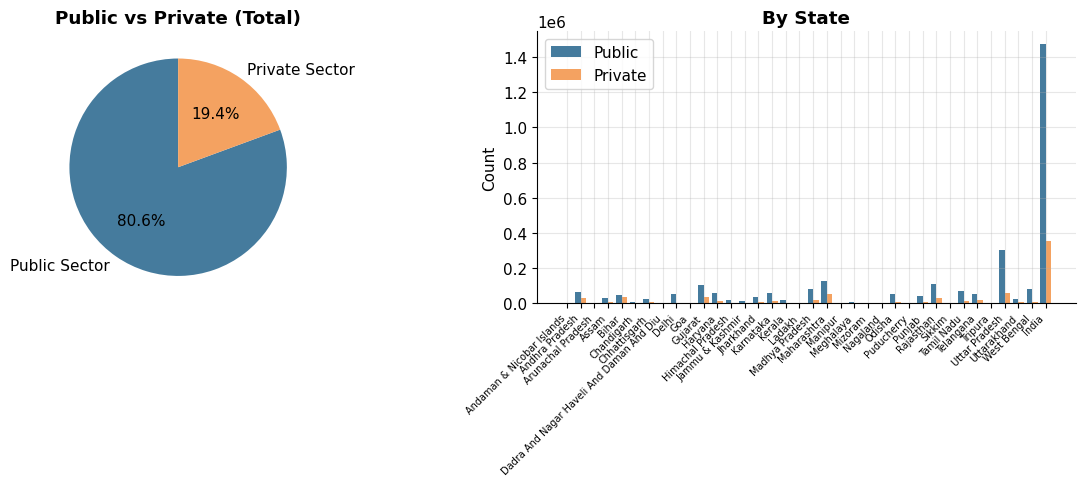

In [21]:
if {'Tobacco_TB_Public_Count', 'Tobacco_TB_Private_Count'}.issubset(tob_clean.columns):
    # Totals
    pub_total = tob_clean['Tobacco_TB_Public_Count'].sum()
    priv_total = tob_clean['Tobacco_TB_Private_Count'].sum()

    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    # Pie chart
    axes[0].pie([pub_total, priv_total],
                labels=['Public Sector', 'Private Sector'],
                autopct='%1.1f%%', startangle=90,
                colors=['#457b9d', '#f4a261'])
    axes[0].set_title('Public vs Private (Total)', fontweight='bold')

    # State‑wise grouped bar
    tob_sector = tob_clean.dropna(subset=['Tobacco_TB_Public_Count', 'Tobacco_TB_Private_Count'])
    x = np.arange(len(tob_sector))
    axes[1].bar(x - 0.2, tob_sector['Tobacco_TB_Public_Count'],
                width=0.4, label='Public', color='#457b9d')
    axes[1].bar(x + 0.2, tob_sector['Tobacco_TB_Private_Count'],
                width=0.4, label='Private', color='#f4a261')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(tob_sector['State'], rotation=45, ha='right', fontsize=7)
    axes[1].set_title('By State', fontweight='bold')
    axes[1].set_ylabel('Count')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('chart8_public_vs_private.png', dpi=150)
    plt.show()
else:
    print("Required columns not found. Check renaming.")

### Chart 9: Cessation Coverage Gap — How Many Tobacco Users Are NOT Getting Help?
**This is the most impactful chart in Part 2 — shows the policy gap clearly.**

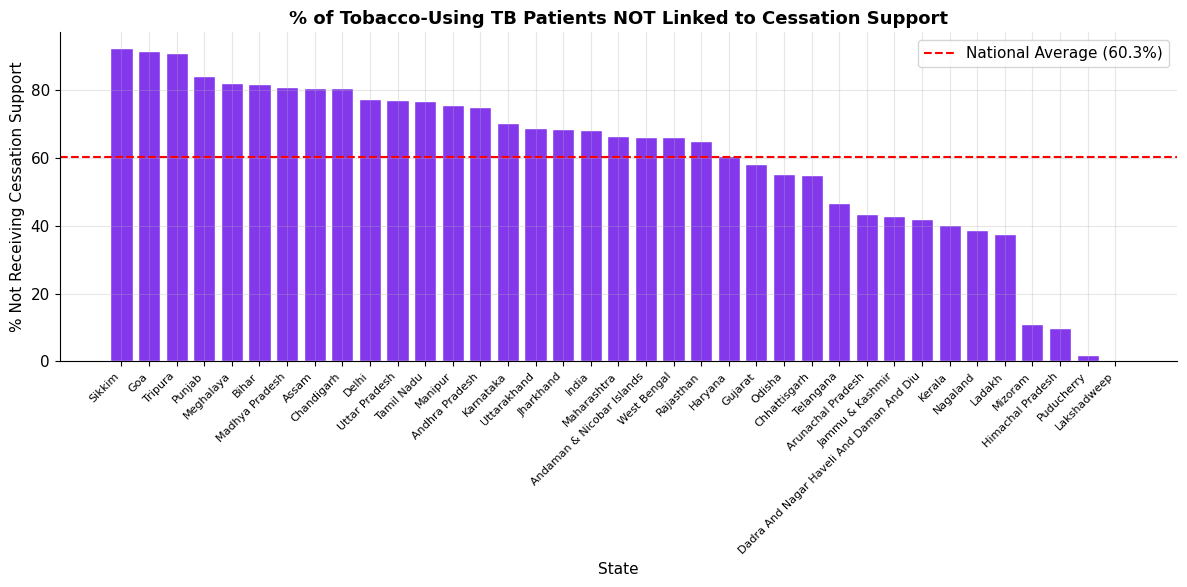

National average: 60.3% of tobacco-using TB patients are NOT getting cessation support.


In [22]:
if {'Tobacco_Users_Total_Count', 'Cessation_Total_Count'}.issubset(tob_clean.columns):
    # Prepare data
    tob_gap = tob_clean.dropna(subset=['Tobacco_Users_Total_Count', 'Cessation_Total_Count']).copy()
    tob_gap['Not_Linked'] = tob_gap['Tobacco_Users_Total_Count'] - tob_gap['Cessation_Total_Count']
    tob_gap['Cessation_Gap_Pct'] = (tob_gap['Not_Linked'] / tob_gap['Tobacco_Users_Total_Count'] * 100).round(1)

    # Sort states by gap
    tob_gap = tob_gap.sort_values('Cessation_Gap_Pct', ascending=False)

    # Plot
    plt.figure(figsize=(12,6))
    plt.bar(tob_gap['State'], tob_gap['Cessation_Gap_Pct'],
            color='#8338ec', edgecolor='white')
    avg_gap = tob_gap['Cessation_Gap_Pct'].mean()
    plt.axhline(avg_gap, color='red', linestyle='--', linewidth=1.5,
                label=f'National Average ({avg_gap:.1f}%)')
    plt.title('% of Tobacco-Using TB Patients NOT Linked to Cessation Support',
              fontsize=13, fontweight='bold')
    plt.xlabel('State')
    plt.ylabel('% Not Receiving Cessation Support')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.legend()
    plt.tight_layout()
    plt.savefig('chart9_cessation_gap.png', dpi=150)
    plt.show()

    print(f"National average: {avg_gap:.1f}% of tobacco-using TB patients are NOT getting cessation support.")
else:
    print("Required columns not found. Check renaming.")

### Chart 10: Top States by Total Tobacco Users Among TB Patients

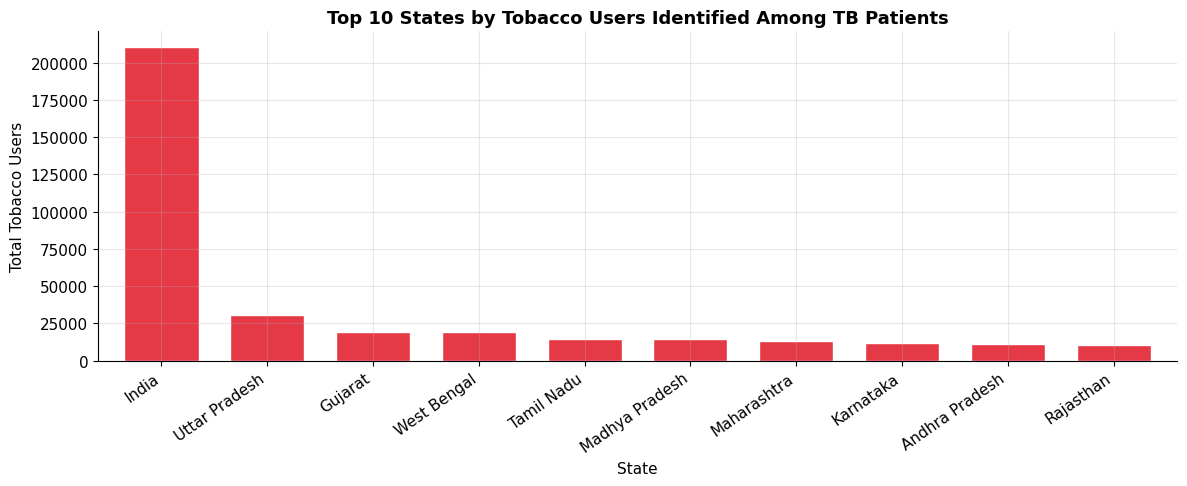

In [23]:
if 'Tobacco_Users_Total_Count' in tob_clean.columns:
    tob_users = tob_clean.dropna(subset=['Tobacco_Users_Total_Count']).sort_values(
        'Tobacco_Users_Total_Count', ascending=False).head(10)

    fig, ax = plt.subplots(figsize=(12, 5))
    tob_users.plot(kind='bar', x='State', y='Tobacco_Users_Total_Count',
                   ax=ax, color='#e63946', edgecolor='white', width=0.7, legend=False)
    ax.set_title('Top 10 States by Tobacco Users Identified Among TB Patients',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('State')
    ax.set_ylabel('Total Tobacco Users')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.savefig('chart10_top_tobacco_states.png', dpi=150, bbox_inches='tight')
    plt.show()


# PART 3: Push Both Datasets to MySQL

We upload both cleaned datasets to MySQL as separate tables:
- `tb_who` — WHO time series data (used for SQL queries and dashboard time series)
- `tb_tobacco` — State-wise tobacco-TB data (used for SQL queries and dashboard Part 2)


In [24]:
import mysql.connector

MYSQL_HOST     = '127.0.0.1'
MYSQL_USER     = 'root'
MYSQL_PASSWORD = 'piku2005' 
MYSQL_DATABASE = 'tb_india'

try:
    # Connect
    conn = mysql.connector.connect(
        host=MYSQL_HOST, user=MYSQL_USER,
        password=MYSQL_PASSWORD, database=MYSQL_DATABASE
    )
    cursor = conn.cursor()
    print("Connected to MySQL!")

    # ── Table 1: WHO TB incidence ──
    cursor.execute("DROP TABLE IF EXISTS tb_who")
    cursor.execute("""
        CREATE TABLE tb_who (
            id INT AUTO_INCREMENT PRIMARY KEY,
            Year INT,
            TB_Incidence FLOAT,
            Treatment_Success FLOAT
        )
    """)

    who_final = tb_incidence.copy()
    if not tb_treatment.empty:
        who_final = who_final.merge(tb_treatment, on="Year", how="left")
    else:
        who_final["Treatment_Success"] = None

    for _, row in who_final.iterrows():
        cursor.execute(
            "INSERT INTO tb_who (Year, TB_Incidence, Treatment_Success) VALUES (%s, %s, %s)",
            (int(row["Year"]),
             None if pd.isna(row["TB_Incidence"]) else float(row["TB_Incidence"]),
             None if pd.isna(row.get("Treatment_Success")) else float(row["Treatment_Success"]))
        )
    print(f"Inserted {len(who_final)} rows into tb_who")

    # ── Table 2: TB Tobacco ──
    cursor.execute("DROP TABLE IF EXISTS tb_tobacco")

    # Build CREATE TABLE from columns
    col_defs = ["id INT AUTO_INCREMENT PRIMARY KEY", "State VARCHAR(100)"]
    for col in tob_clean.columns:
        if col != "State":
            col_defs.append(f"`{col}` FLOAT")
    cursor.execute(f"CREATE TABLE tb_tobacco ({', '.join(col_defs)})")

    for _, row in tob_clean.iterrows():
        cols = ["State"] + [c for c in tob_clean.columns if c != "State"]
        vals = [row["State"]] + [None if pd.isna(row[c]) else float(row[c]) for c in tob_clean.columns if c != "State"]
        placeholders = ", ".join(["%s"] * len(vals))
        cursor.execute(f"INSERT INTO tb_tobacco ({', '.join([f'`{c}`' for c in cols])}) VALUES ({placeholders})", vals)
    print(f"Inserted {len(tob_clean)} rows into tb_tobacco")

    # Commit and close
    conn.commit()
    cursor.close()
    conn.close()
    print("\nAll data uploaded successfully!")

except Exception as e:
    print("Error:", e)


Connected to MySQL!
Inserted 25 rows into tb_who
Inserted 37 rows into tb_tobacco

All data uploaded successfully!



## Step 8: Key Insights 


In [25]:
print('=' * 65)
print('KEY FINDINGS')
print('=' * 65)

# Part 1 insights
first = national.iloc[0]
last  = national.iloc[-1]
change = last['TB_Incidence'] - first['TB_Incidence']
pct_change = change / first['TB_Incidence'] * 100
print(f'\nPart 1 — National Trend:')
print(f'  TB fell from {first["TB_Incidence"]:.1f} ({int(first["Year"])}) '
      f'to {last["TB_Incidence"]:.1f} ({int(last["Year"])}) per 100,000')
print(f'  Total reduction: {abs(pct_change):.1f}% over {int(last["Year"]-first["Year"])} years')
print(f'  Annual drop rate: {abs(slope):.2f} per 100k/year')

# Part 2 insights
if 'Tobacco_TB_Total_Pct' in tob_clean.columns:
    worst_state = tob_clean.dropna(subset=['Tobacco_TB_Total_Pct']).sort_values(
        'Tobacco_TB_Total_Pct', ascending=False).iloc[0]
    nat_avg = tob_clean['Tobacco_TB_Total_Pct'].mean()
    print(f'\nPart 2 — Tobacco-TB Risk:')
    print(f'  National avg tobacco usage among TB patients: {nat_avg:.1f}%')
    print(f'  Worst state: {worst_state["State"]} at {worst_state["Tobacco_TB_Total_Pct"]:.1f}%')

if 'Cessation_Gap_Pct' in tob_gap.columns if 'tob_gap' in dir() else False:
    avg_gap = tob_gap['Cessation_Gap_Pct'].mean()
    print(f'  Average cessation coverage gap: {avg_gap:.1f}%')
    print(f'  i.e. {avg_gap:.0f}% of tobacco-using TB patients get NO quit-smoking support')

print('\nRecommendation:')
print('  1. India needs to accelerate TB reduction to meet the 2025 target')
print('  2. States with high tobacco-TB burden need targeted dual interventions')
print('  3. Cessation programme coverage must be scaled up urgently')
print('=' * 65)


KEY FINDINGS

Part 1 — National Trend:
  TB fell from 180.5 (2000) to 187.0 (2024) per 100,000
  Total reduction: 3.6% over 24 years
  Annual drop rate: 3.09 per 100k/year

Part 2 — Tobacco-TB Risk:
  National avg tobacco usage among TB patients: 81.5%
  Worst state: Lakshadweep at 100.0%
  Average cessation coverage gap: 60.3%
  i.e. 60% of tobacco-using TB patients get NO quit-smoking support

Recommendation:
  1. India needs to accelerate TB reduction to meet the 2025 target
  2. States with high tobacco-TB burden need targeted dual interventions
  3. Cessation programme coverage must be scaled up urgently



**Project:** India TB Elimination Intelligence — Dual Dataset Analysis

**What I did:**
1. Loaded and cleaned two real Indian health datasets — WHO TB indicators and NTEP Tobacco-TB data
2. Built 10 EDA charts across two parts — national time series and state-wise risk factor analysis
3. Applied time series decomposition to separate TB trend from noise
4. Built a linear projection to quantify India's gap from the 2025 elimination target
5. Analysed cessation programme coverage gaps — how many tobacco-using TB patients get no support
6. Uploaded both datasets to MySQL as separate tables for SQL analysis
7. Built an interactive Streamlit dashboard combining both datasets
